In [1]:
# Name: Saravanan
# Roll No: 24BAD105
# Experiment: Polynomial Regression – Auto MPG Dataset

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# 2. Load Dataset
df = pd.read_csv("auto-mpg.csv")

In [3]:
# 4. Handle Missing Values
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df = df.dropna()

X = df[['horsepower']]
y = df['mpg']

In [4]:
# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


Polynomial Degree: 2
Train RMSE: 4.382306891578572
Test RMSE: 4.291499481069267
R2 Score: 0.6391701147013312


c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


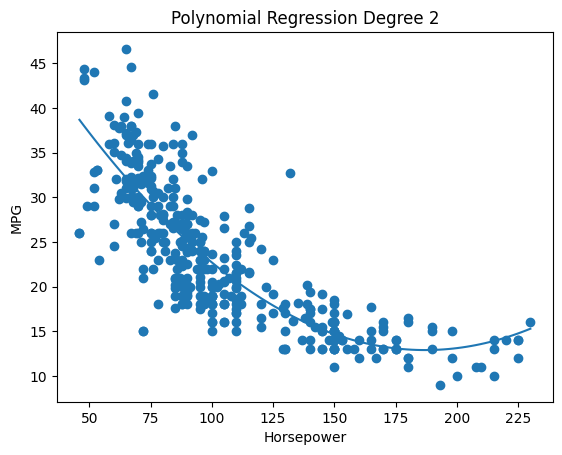


Polynomial Degree: 3
Train RMSE: 4.375361474747155
Test RMSE: 4.296541309265468
R2 Score: 0.6383217814053861


c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


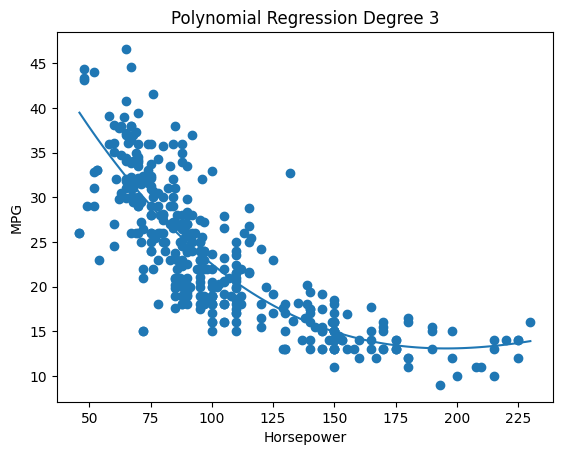


Polynomial Degree: 4
Train RMSE: 4.373350128219759
Test RMSE: 4.274134634619407
R2 Score: 0.6420842844016579


c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


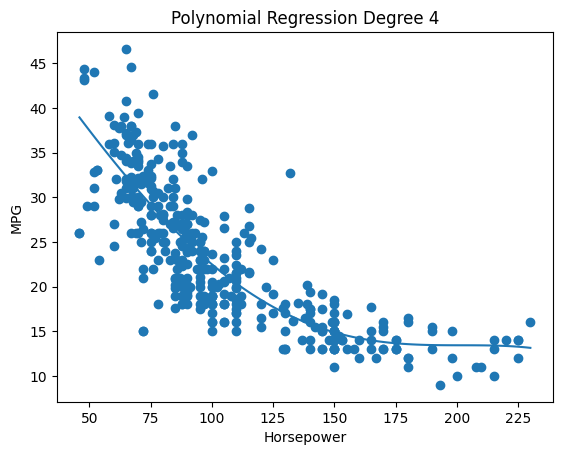

In [6]:
# 6. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

degrees = [2, 3, 4]

for degree in degrees:
    print("\nPolynomial Degree:", degree)
    
    # Generate Polynomial Features
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)
    
    # Train Model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    
    # Evaluation
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    print("Train RMSE:", np.sqrt(train_mse))
    print("Test RMSE:", np.sqrt(test_mse))
    print("R2 Score:", r2_score(y_test, y_test_pred))
    
    # Visualization
    X_range = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
    X_range_scaled = scaler.transform(X_range)
    X_range_poly = poly.transform(X_range_scaled)
    y_range_pred = model.predict(X_range_poly)
    
    plt.scatter(X, y)
    plt.plot(X_range, y_range_pred)
    plt.title(f"Polynomial Regression Degree {degree}")
    plt.xlabel("Horsepower")
    plt.ylabel("MPG")
    plt.show()